In [17]:
"""Inserts"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Callable


### Test

In [2]:
"""Reading data"""
training_data=pd.read_parquet("data_parquet_2026/train.parquet")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet")
test_data = pd.read_parquet("data_parquet_2026/test.parquet")

In [3]:
""" Ségrégation des profiles"""
n=int(len(training_data["power"])/len(training_data["sensor"].unique())/3) #27384/3 = 9128
power1 = training_data.query("sensor =='N0000'")
power2 = training_data.query("sensor =='N0000'")
power3 = training_data.query("sensor =='N0000'")

for senso in training_data["sensor"].unique():
    power1 = pd.concat((power1, training_data[training_data["sensor"] == senso][:n]))
    power2 = pd.concat((power2, training_data[training_data["sensor"] == senso][n+1:2*n]))
    power3 = pd.concat((power3, training_data[training_data["sensor"] == senso][2*n+1:]))

#power1.plot.scatter(x="time", y="power", alpha=0.5)
#power2.plot.scatter(x="time", y="power", alpha=0.5)
#power3.plot.scatter(x="time", y="power", alpha=0.5)

In [4]:
training_data.info()
#training_data.head(5)
training_data["sensor"]
sensors["sensor"]
#test_data.sample(15)
#sensors.info()
#sensors.query("coor_z == 0") #tous =0
#sensors.head(21)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB


0        N2
1        N4
2        N5
3        N6
4        N7
       ... 
320    N869
321    N871
322    N873
323    N877
324    N878
Name: sensor, Length: 325, dtype: category
Categories (323, object): ['N102', 'N103', 'N104', 'N108', ..., 'N928', 'N929', 'N96', 'N98']

<Axes: xlabel='time', ylabel='temperature'>

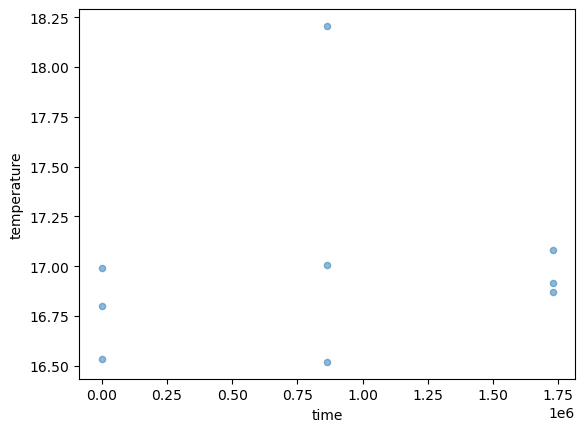

In [5]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("time <= 1800000 and sensor=='N418'")
sampleP.head(10)

sampleP.plot.scatter(x="time", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

,sensor,time,power,temperature
803264,N418,0.0,1487.964722,16.798691
803265,N418,864000.0,1487.288818,18.206434
803266,N418,1728000.0,1486.612915,17.079123
803267,N418,2592000.0,1485.936890,17.537308
803268,N418,3456000.0,1485.260986,17.180557


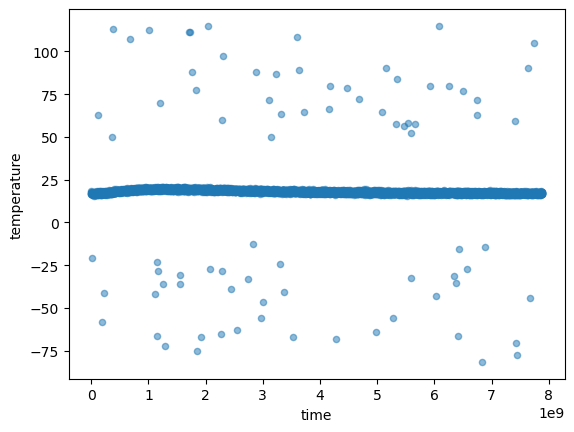

In [6]:
"""graphes tous pour 1 senseur"""

sampleN418 = power1.query(" sensor=='N418'")
#sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418.plot.scatter(x="time", y="temperature", alpha=0.5)
sensors.query("sensor == 'N418'")
sampleN418.head()

<Axes: xlabel='time', ylabel='temperature'>

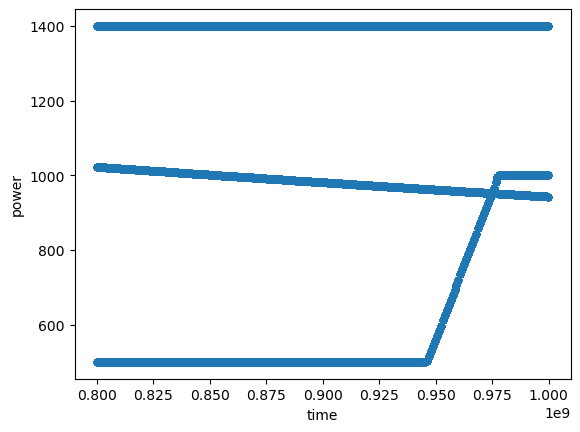

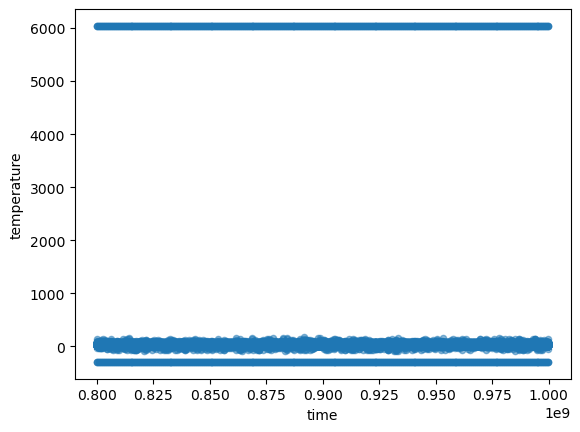

In [7]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)



<Axes: xlabel='power', ylabel='temperature'>

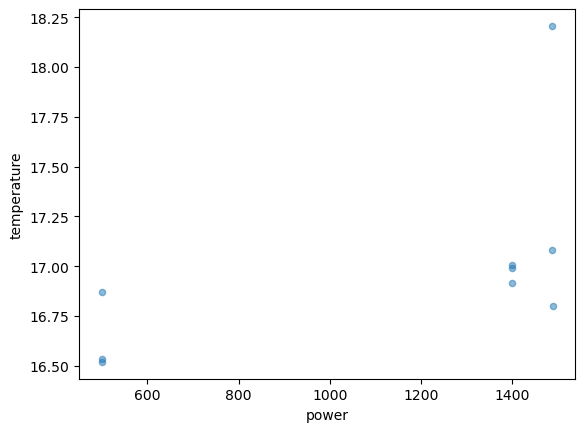

In [4]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("time <= 1800000 and sensor=='N418'")
sampleP.head(10)

sampleP.plot.scatter(x="power", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

<Axes: xlabel='time', ylabel='power'>

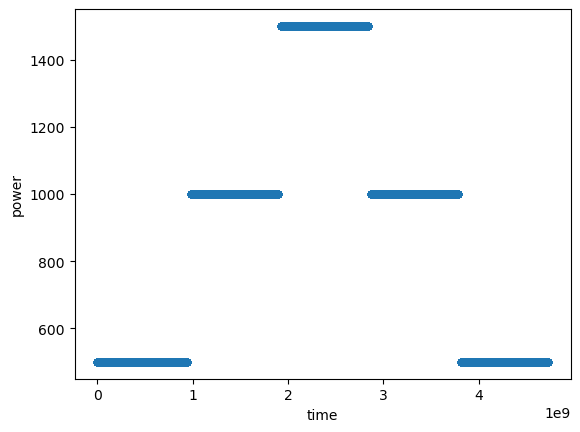

In [5]:
a = sampleP["power"].diff(periods=864000)

a.head(20)
power1 = training_data.query("power == 500.0000 or power == 1000.0000 or power == 1500.0000")
power1.plot.scatter(x="time", y="power", alpha=0.5)


,sensor,coor_x,coor_y,coor_z
186,N418,34.596756,2.682129,0.0


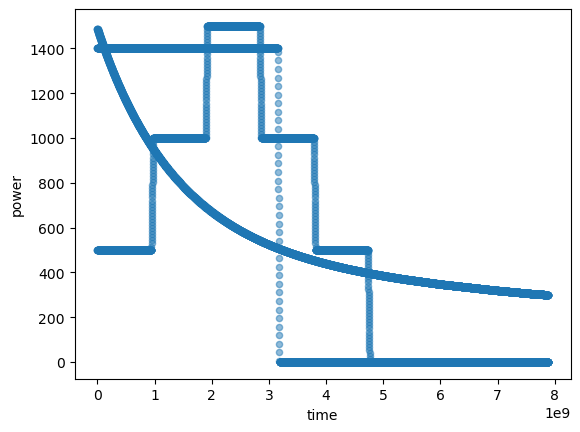

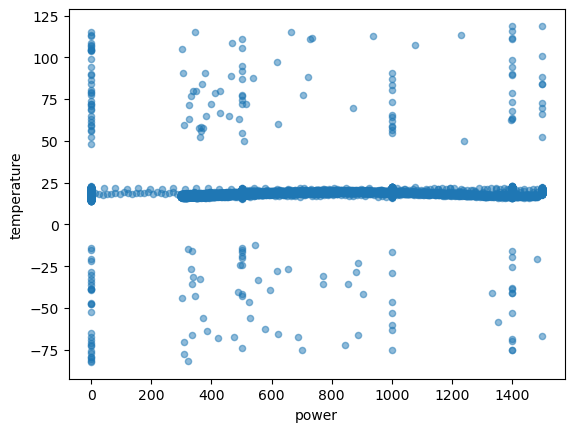

In [6]:
"""graphes tous pour 1 senseur"""

sampleN418 = training_data.query(" sensor=='N418'")
sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418.plot.scatter(x="power", y="temperature", alpha=0.5)
sensors.query("sensor == 'N418'")

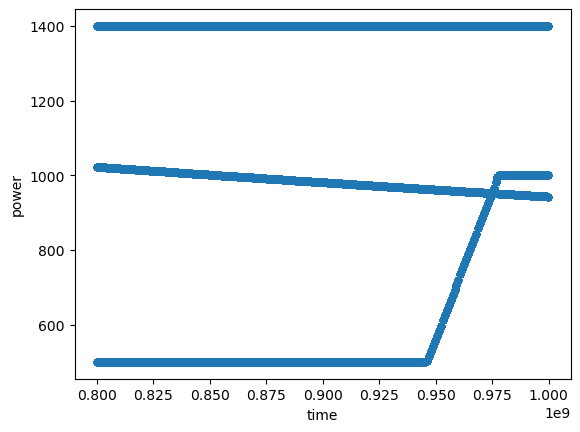

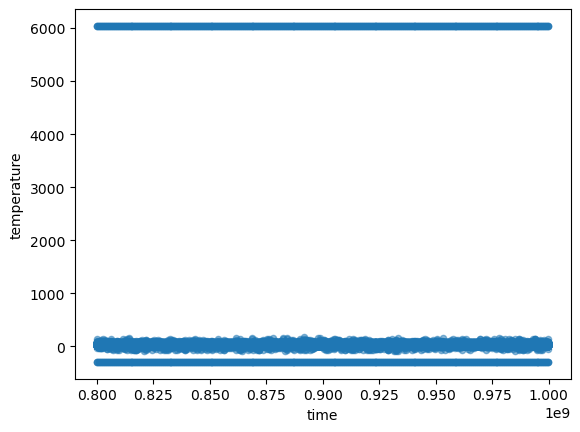

In [7]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)
c=b["power"].pct_change(periods=1)


<Axes: xlabel='time', ylabel='temperature'>

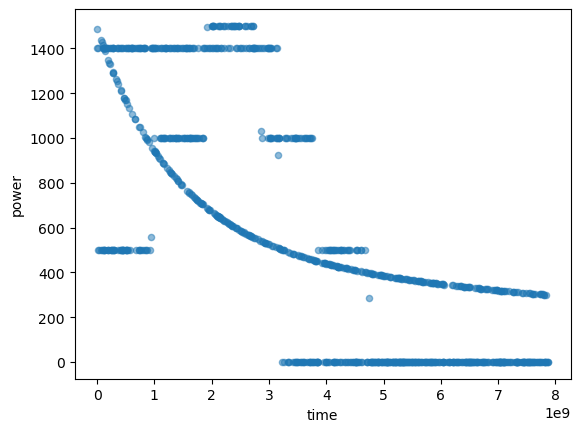

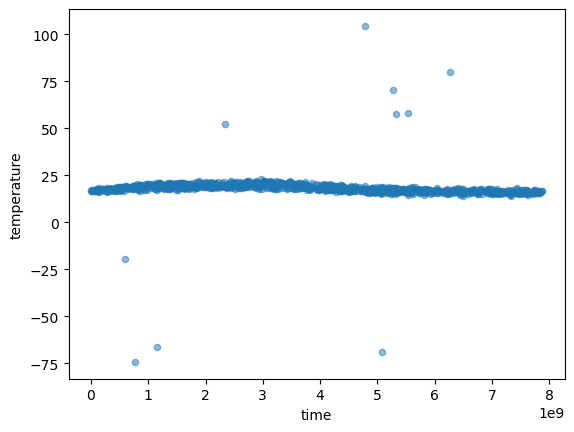

In [8]:
sampleN418b = sampleN418.sample(1000)
sampleN418b.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418b.plot.scatter(x="time", y="temperature", alpha=0.5)


## I. First Model

### 1. Distance Metrics

In [9]:
def man_dist(sample_coo: np.ndarray, X: np.ndarray) -> np.ndarray:

    """Computes the Manhattan distance between a sample and the sensors.
    Args:
        sample_coo: Coordinates of the sample, of shape (D, )
        X: Dataset of the sensors' coordinates, of shape (N, D)
    Returns:
        dist: Distances of shape (N,)
    """

    return np.abs(X - sample_coo).sum(axis = 1)
   


def eucli_dist(sample_coo: np.ndarray, X: np.ndarray) -> np.ndarray:

    """Computes the Euclidean distance between a sample and the sensors.
    Args:
        sample_coo: Coordinates of the sample, of shape (D, )
        X: Dataset of the sensors' coordinates, of shape (N, D)
    Returns:
        dist: Distances of shape (N,)
    """ 
   
    return np.sqrt(((X - sample_coo) ** 2).sum(axis = 1))

### 2. Distance Score

In [10]:
def distance_score(sample_coo: np.ndarray,
                   X: np.ndarray,
                   distance_fn: Callable = eucli_dist,
                   score_parameter: float = 1) -> np.ndarray:
    
    """Gives a score to each given sensor, depending on their distance to sample.
    The closer is the sample, the higher the score. We set an upper limit to it
    to avoid giving "blind confidence" to "very close" sensors.
    Args:
        sample_coo: Coordinates of the sample, of shape (D, )
        X: Dataset of the sensors' coordinates, of shape (N, D)
        function: Distance function chosen
        score_parameter: Hyper-parameter, set to 1 by default
    Returns:
        dist: Distances of shape (N,)
    """

    distance = distance_fn(sample_coo, X)
    score = 1 / (score_parameter*distance + 1)
    
    return score


### 3. Missing Values manager

In [ ]:
def managing_missing_val(sens : pd.DataFrame):
    
    """
    """
    
    sens = sens.reset_index(drop=True)
    temp = 0
    memo = []
    for i,val in enumerate(sens["temperature"]):
        
        if not val==val: # if nan
            memo.append(i)       
                     
        else: # c'est pas un nan
            if type(temp)!=int: # si on a une valeur en mémoire
                if len(memo)!=0: # et qu'il y avait des nan avant
                    sens.loc[memo,"temperature"]=(temp+sens["temperature"][i])/2 #on remplace les nan par la moyenne de la mémoire et l'actuel
                    memo=[] # on oublie
                temp=sens["temperature"][i]
                
            else: # pas de valeur en mémoire
                if len(memo)!=0: # mais des nan avant
                    sens.loc[memo,"temperature"]=sens["temperature"][i] # on remplaces les nan par la valeur d'après
                    memo=[] # on oublie
        
    return sens

### 4. K-Nearest Neigbors

In [ ]:
def find_nearest_neighbors(
    sample_coo: np.ndarray, 
    X: np.ndarray, 
    distance_fn: Callable = eucli_dist, 
    k: int = 7):
    
    """Finds the indices of the k-Nearest Neighbors to a sample
    Args:
        sample_coo: Coordinates of the sample, of shape (D, )
        X: Dataset of the the sensors' coordinates, of shape (N, D)
        distance_fn: Distance function
        k: Number of nearest neighbors taken, set to 7 by default

    Returns:
        indices: Neighbor indices of shape (k, )
    """

    distances = distance_fn(sample_coo, X)
    neighbor_indices = np.argsort(distances)[:k]

    
    return neighbor_indices

# sens_coo = np.array([sensors["coor_x"],sensors["coor_y"]]).T
# nearest_sensors = sensors["sensor"][find_nearest_neighbors(..., sens_coo)] # A compléter avec sample_coo

### Tests post-fonctions

In [10]:
sampleN418.isna().sum()
a=managing_missing_val(sampleN418)
a.isna().sum()

sensor         0
time           0
power          0
temperature    0
dtype: int64